# 🫒 Détection des Maladies de l'Olivier par Deep Learning

---

| Informations | Détails |
|---|---|
| **Étudiant** | Ahmed Bouriga |
| **Encadrant** | M. Abdallah Khemais |
| **Notebook** | 1 / 6 — Setup & Exploration du Dataset |
| **Dataset** | Zeytin_224x224_Augmented (Kaggle) |
| **Modèle cible** | EfficientNetB4 |

---

## 🎯 Objectif de ce Notebook

Ce premier notebook couvre les étapes suivantes :
1. ✅ Vérification du **GPU** disponible sur Kaggle
2. ✅ Installation et import de toutes les **librairies**
3. ✅ Exploration de la **structure du dataset**
4. ✅ Calcul des **statistiques** par classe
5. ✅ Visualisation de la **distribution des classes**
6. ✅ Affichage d'**exemples visuels** par classe
7. ✅ Analyse des **dimensions et couleurs** des images
8. ✅ Sauvegarde de la **configuration** du projet en JSON

---

## 📦 Informations sur le Dataset

| Propriété | Valeur |
|---|---|
| Nom | Zeytin_224x224_Augmented |
| Source | Kaggle — serhathoca/zeytin |
| Total images | 6 961 images |
| Classe 1 | ✅ Healthy (feuille saine) |
| Classe 2 | 🔴 Peacock Spot (œil de paon) |
| Classe 3 | 🟠 Aculus Olearius (acarien du rameau) |
| Taille images | 224 × 224 pixels |

---

> ⚠️ **Avant de commencer :** Ajouter le dataset sur Kaggle :
> 1. Cliquer sur **+ Add Data** (colonne droite)
> 2. Chercher `zeytin` ou `serhathoca`
> 3. Ajouter le dataset **Zeytin_Yaprak_224_Aug**
> 4. Activer le GPU : **Settings → Accelerator → GPU T4**

---
## 🔧 Cellule 1 — Vérification du GPU

> **Explication :** La première étape est de vérifier que Kaggle met à disposition un **GPU** pour accélérer l'entraînement.
> - Le GPU est **10 à 50 fois plus rapide** que le CPU pour entraîner des modèles Deep Learning.
> - Kaggle offre le GPU **T4 gratuitement** pendant 30h par semaine.
> - Si le résultat affiche `False` → aller dans **Settings → Accelerator → GPU T4**.

In [1]:
# ============================================================
# Cellule 1 — Vérification du GPU
# On vérifie si Kaggle fournit bien un GPU pour l'entraînement
# ============================================================

import torch
import tensorflow as tf
import sys

print('=' * 55)
print('Vérification de l\'environnement de travail')
print('=' * 55)

# Vérification GPU via PyTorch
gpu_ok = torch.cuda.is_available()
print(f'\nGPU disponible (PyTorch)    : {gpu_ok}')
if gpu_ok:
    print(f'  Nom du GPU               : {torch.cuda.get_device_name(0)}')
    mem_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'  Mémoire GPU              : {mem_gb:.1f} GB')
else:
    print('  ATTENTION : Aucun GPU detecte !')
    print('  --> Aller dans Settings → Accelerator → GPU T4')

# Vérification GPU via TensorFlow
tf_gpus = tf.config.list_physical_devices('GPU')
print(f'\nGPU disponible (TensorFlow) : {len(tf_gpus) > 0}')
print(f'  TensorFlow version        : {tf.__version__}')
print(f'  Python version            : {sys.version.split()[0]}')

print('\n' + '=' * 55)
if gpu_ok:
    print('Environnement pret pour l\'entrainement !')
else:
    print('Activer le GPU avant de continuer !')
print('=' * 55)

2026-05-13 13:46:29.937346: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778679990.166008      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778679990.239235      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778679990.772372      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778679990.772417      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778679990.772419      24 computation_placer.cc:177] computation placer alr

Vérification de l'environnement de travail

GPU disponible (PyTorch)    : True
  Nom du GPU               : Tesla T4
  Mémoire GPU              : 15.6 GB

GPU disponible (TensorFlow) : True
  TensorFlow version        : 2.19.0
  Python version            : 3.12.12

Environnement pret pour l'entrainement !


---
## 📦 Cellule 2 — Import des Librairies

> **Explication :** On importe toutes les librairies nécessaires pour l'ensemble du projet :
> - **NumPy / Pandas** → calculs mathématiques et gestion des données tabulaires
> - **Matplotlib / Seaborn** → visualisations graphiques
> - **OpenCV / PIL** → lecture et traitement des images
> - **TensorFlow / Keras** → construction et entraînement des modèles Deep Learning
> - **OS / JSON / Pathlib** → gestion des fichiers et dossiers

In [2]:
# ============================================================
# Cellule 2 — Import des Librairies
# On installe les librairies manquantes et on importe tout
# ============================================================

# Installation des librairies non présentes par défaut sur Kaggle
!pip install -q opencv-python-headless seaborn

# -- Librairies de données ----------------------------------
import numpy as np              # Calculs sur tableaux et matrices
import pandas as pd             # Manipulation de données tabulaires

# -- Librairies de visualisation ---------------------------
import matplotlib.pyplot as plt       # Graphiques de base
import matplotlib.gridspec as gridspec # Grille de sous-graphiques
import seaborn as sns                  # Graphiques statistiques avancés

# -- Librairies de traitement d'images ---------------------
import cv2                      # OpenCV : lecture et transformation d'images
from PIL import Image           # Pillow : ouverture et conversion d'images

# -- Librairies système et fichiers ------------------------
import os                       # Navigation dans le système de fichiers
import json                     # Lecture/écriture de fichiers JSON
import warnings                 # Suppression des avertissements
from pathlib import Path        # Gestion moderne des chemins de fichiers
from collections import Counter # Comptage d'éléments

# -- Librairies TensorFlow / Keras -------------------------
import tensorflow as tf
from tensorflow import keras

# -- Configuration générale --------------------------------
warnings.filterwarnings('ignore')         # Masquer les avertissements
np.random.seed(42)                        # Fixer le seed pour reproducibilité
tf.random.set_seed(42)
plt.rcParams['figure.dpi']  = 120        # Résolution des figures
plt.rcParams['font.size']   = 11         # Taille de police par défaut
plt.style.use('seaborn-v0_8-whitegrid')  # Style graphique propre

print('Toutes les librairies importees avec succes !')
print(f'  numpy      : {np.__version__}')
print(f'  pandas     : {pd.__version__}')
print(f'  opencv     : {cv2.__version__}')
print(f'  tensorflow : {tf.__version__}')

Toutes les librairies importees avec succes !
  numpy      : 2.0.2
  pandas     : 2.3.3
  opencv     : 4.13.0
  tensorflow : 2.19.0


---
## 📂 Cellule 3 — Exploration de la Structure du Dataset

> **Explication :** On localise le dataset dans l'arborescence Kaggle et on explore sa structure.
> - Sur Kaggle, tous les datasets ajoutés sont accessibles dans `/kaggle/input/`
> - Chaque sous-dossier correspond à une **classe** (Healthy, Peacock Spot, Aculus Olearius)
> - On teste automatiquement plusieurs chemins possibles pour trouver le dataset

In [3]:
# ============================================================
# Cellule 3 (CORRIGÉE) — Exploration de la Structure du Dataset
# On cherche automatiquement le dataset n'importe où dans /kaggle/input/
# ============================================================

import os

print('Recherche automatique du dataset...')
print('=' * 55)

DATASET_PATH = None

# os.walk va fouiller dans absolument tous les sous-dossiers
for root, dirs, files in os.walk('/kaggle/input'):
    # On cherche s'il y a des images dans le dossier actuel
    imgs = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
    
    if len(imgs) > 0:
        # Si on trouve des images, le dossier racine est le DATASET_PATH
        DATASET_PATH = os.path.dirname(root)
        break

if DATASET_PATH:
    print(f'✅ Dataset trouvé avec succès !')
    print(f'Chemin : {DATASET_PATH}\n')
    
    print('Classes trouvées :')
    for sub in sorted(os.listdir(DATASET_PATH)):
        sub_path = os.path.join(DATASET_PATH, sub)
        if os.path.isdir(sub_path):
            imgs = [f for f in os.listdir(sub_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
            print(f'  📁 {sub:<20} --> {len(imgs)} images')
else:
    print('❌ Dataset toujours introuvable. Veuillez vérifier l\'importation.')

Recherche automatique du dataset...
✅ Dataset trouvé avec succès !
Chemin : /kaggle/input/datasets/hikmetdurmaz/zeytin-yaprak-224-aug/Zeytin_224x224_Augmented/val

Classes trouvées :
  📁 Kus_Gozu_Mantari     --> 460 images
  📁 Pas_Akari            --> 290 images
  📁 Saglikli             --> 230 images


---
## 📊 Cellule 4 — Statistiques par Classe

> **Explication :** On calcule le nombre d'images par classe et on analyse l'équilibre du dataset.
> - Un **dataset équilibré** signifie que chaque classe a approximativement le même nombre d'images.
> - Un **déséquilibre** (imbalance) peut biaiser le modèle vers les classes majoritaires.
> - L'**Imbalance Ratio** = nombre d'images dans la classe la plus grande / la plus petite.

In [4]:
# ============================================================
# Cellule 4 — Statistiques par Classe
# On compte les images par classe et on analyse l'équilibre
# ============================================================

class_counts  = {}  # Nombre d'images par classe
class_paths   = {}  # Chemin complet de chaque classe
class_samples = {}  # Liste des noms de fichiers par classe

# Lecture de chaque sous-dossier (= une classe)
for cls in sorted(os.listdir(DATASET_PATH)):
    cls_dir = os.path.join(DATASET_PATH, cls)
    if not os.path.isdir(cls_dir):
        continue  # Ignorer les fichiers, ne garder que les dossiers
    imgs = [
        f for f in os.listdir(cls_dir)
        if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))
    ]
    class_counts[cls]  = len(imgs)
    class_paths[cls]   = cls_dir
    class_samples[cls] = imgs

# Affichage des statistiques
total = sum(class_counts.values())

print('=' * 62)
print('Distribution des images par classe')
print('=' * 62)
print(f'{"Classe":<32} {"Nb images":>10}  {"Pourcentage":>12}')
print('-' * 62)

for cls, cnt in class_counts.items():
    pct = cnt / total * 100
    bar = '|' * int(pct / 3)
    print(f'  {cls:<30} {cnt:>10,}  {pct:>10.1f}%  {bar}')

print('-' * 62)
print(f'  {"TOTAL":<30} {total:>10,}  {100.0:>10.1f}%')
print('=' * 62)

# Analyse du déséquilibre
mx, mn = max(class_counts.values()), min(class_counts.values())
ratio  = mx / mn
print(f'\nImbalance Ratio : {ratio:.2f}x')
if ratio < 1.5:
    print('  --> Dataset bien equilibre')
elif ratio < 3.0:
    print('  --> Léger déséquilibre --> on utilisera class_weight dans NB-3')
else:
    print('  --> Fort déséquilibre --> Data Augmentation obligatoire dans NB-2')

Distribution des images par classe
Classe                            Nb images   Pourcentage
--------------------------------------------------------------
  Kus_Gozu_Mantari                      460        46.9%  |||||||||||||||
  Pas_Akari                             290        29.6%  |||||||||
  Saglikli                              230        23.5%  |||||||
--------------------------------------------------------------
  TOTAL                                 980       100.0%

Imbalance Ratio : 2.00x
  --> Léger déséquilibre --> on utilisera class_weight dans NB-3


---
## 📊 Cellule 5 — Visualisation de la Distribution des Classes

> **Explication :** On trace deux graphiques pour visualiser la répartition des images :
> - **Bar Chart** → affiche le nombre exact d'images par classe
> - **Pie Chart** → affiche le pourcentage de chaque classe
> - Ces graphiques seront intégrés dans le README GitHub et la présentation PowerPoint.

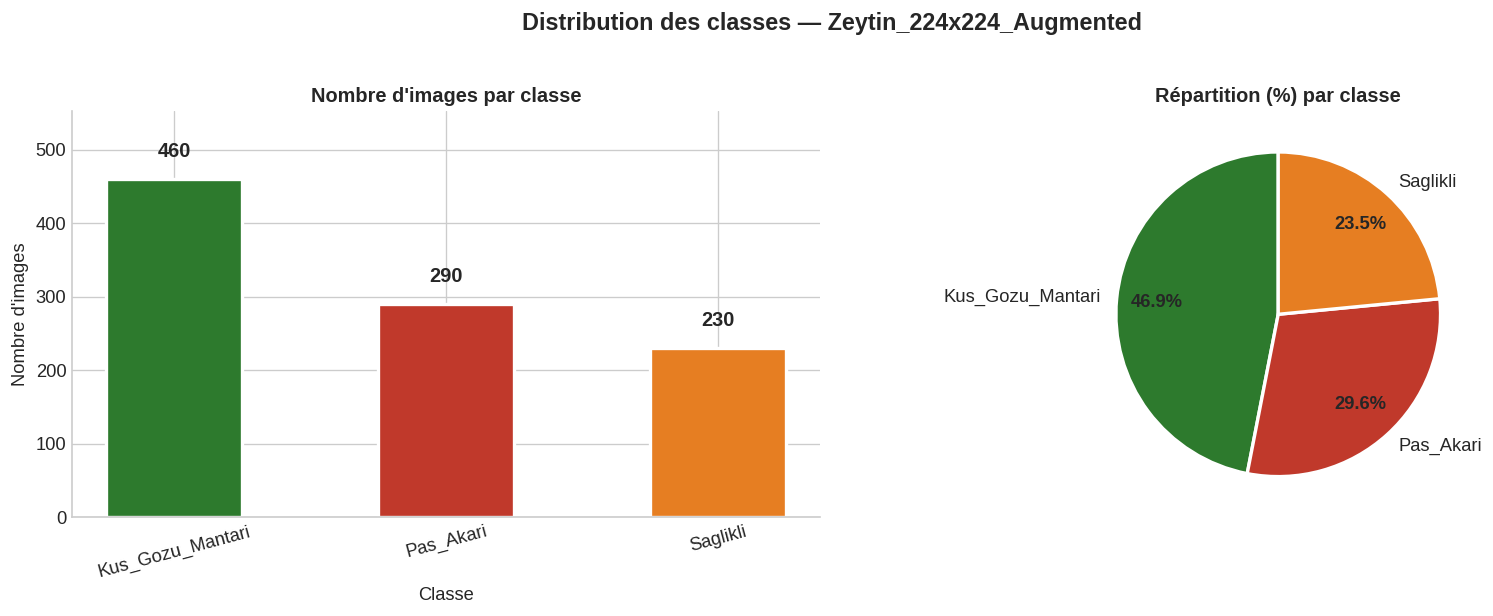

Figure sauvegardée --> /kaggle/working/01_class_distribution.png


In [5]:
# ============================================================
# Cellule 5 — Visualisation de la Distribution
# Bar Chart + Pie Chart de la répartition des classes
# ============================================================

COLORS  = ['#2d7a2d', '#c0392b', '#e67e22']  # Vert, Rouge, Orange
classes = list(class_counts.keys())
counts  = list(class_counts.values())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Distribution des classes — Zeytin_224x224_Augmented',
    fontsize=14, fontweight='bold', y=1.02
)

# -- Bar Chart ---------------------------------------------
bars = axes[0].bar(
    classes, counts,
    color=COLORS, edgecolor='white', linewidth=2, width=0.5
)
# Affichage des valeurs au-dessus des barres
for bar, cnt in zip(bars, counts):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        f'{cnt:,}',
        ha='center', fontsize=12, fontweight='bold'
    )
axes[0].set_title('Nombre d\'images par classe', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Nombre d\'images')
axes[0].set_ylim(0, max(counts) * 1.2)
axes[0].tick_params(axis='x', rotation=15)
axes[0].spines[['top', 'right']].set_visible(False)

# -- Pie Chart ---------------------------------------------
wedges, texts, autotexts = axes[1].pie(
    counts, labels=classes, colors=COLORS,
    autopct='%1.1f%%', startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for t in autotexts:
    t.set_fontsize(11)
    t.set_fontweight('bold')
axes[1].set_title('Répartition (%) par classe', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/01_class_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée --> /kaggle/working/01_class_distribution.png')

---
## 🖼️ Cellule 6 — Visualisation des Exemples par Classe

> **Explication :** On affiche 5 images par classe pour observer visuellement les différences entre :
> - 🟢 **Healthy** → feuille verte, uniforme, sans taches
> - 🔴 **Peacock Spot** → taches circulaires brunes avec halo jaune (Spilocaea oleagina)
> - 🟠 **Aculus Olearius** → déformation et décoloration par l'acarien microscopique
>
> **Pourquoi c'est important ?** Le modèle va apprendre automatiquement ces différences visuelles !

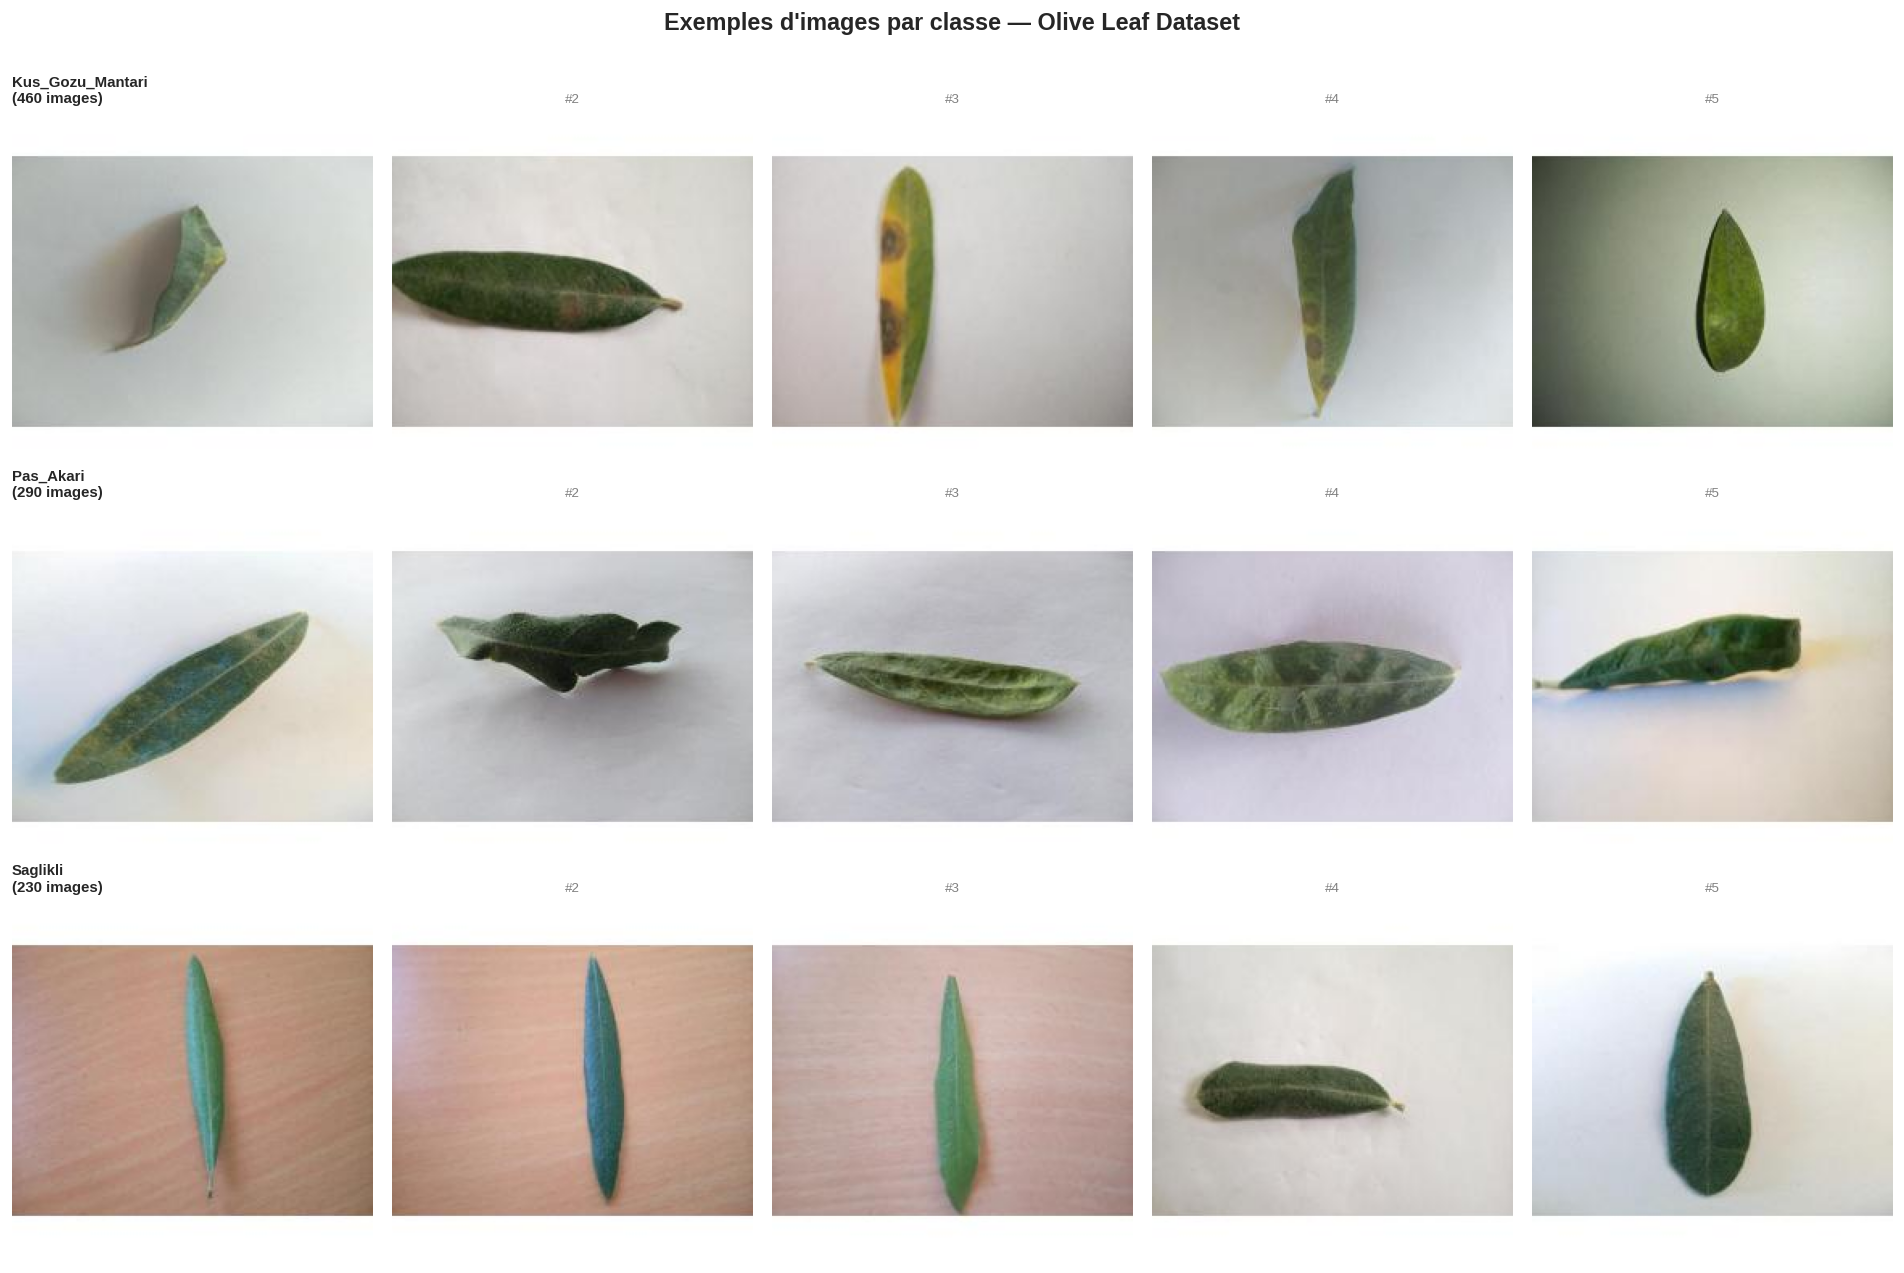

Figure sauvegardée --> /kaggle/working/02_sample_images.png


In [6]:
# ============================================================
# Cellule 6 — Visualisation des Exemples par Classe
# On affiche 5 images de chaque classe pour voir les différences
# ============================================================

N_COLS = 5  # Nombre d'images à afficher par classe
N_ROWS = len(class_paths)

fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(16, N_ROWS * 3.5))
fig.suptitle(
    'Exemples d\'images par classe — Olive Leaf Dataset',
    fontsize=14, fontweight='bold', y=1.01
)

for row, (cls_name, cls_dir) in enumerate(class_paths.items()):
    # Sélection des 5 premières images de la classe
    sample_imgs = class_samples[cls_name][:N_COLS]

    for col, img_name in enumerate(sample_imgs):
        img_path = os.path.join(cls_dir, img_name)

        # Lecture et conversion BGR → RGB
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (224, 224))

        ax = axes[row, col]
        ax.imshow(img)
        ax.axis('off')

        # Titre : nom de classe sur la première image de chaque ligne
        if col == 0:
            ax.set_title(
                f'{cls_name}\n({class_counts[cls_name]} images)',
                fontsize=9, fontweight='bold', loc='left'
            )
        else:
            ax.set_title(f'#{col + 1}', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('/kaggle/working/02_sample_images.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée --> /kaggle/working/02_sample_images.png')

---
## 📐 Cellule 7 — Analyse des Dimensions des Images

> **Explication :** Avant d'entraîner un modèle, il est essentiel de connaître les dimensions des images du dataset.
> - Tous les modèles CNN nécessitent une **taille d'entrée fixe** (ici : 224×224 pixels)
> - On vérifie que toutes les images sont bien en **3 canaux RGB**
> - L'analyse des dimensions confirme si un redimensionnement (resize) est nécessaire

Propriétés des images du dataset
  Largeur  (pixels) — min: 224, max: 224, moyenne: 224
  Hauteur  (pixels) — min: 224, max: 224, moyenne: 224
  Taille fichier    — moyenne: 3.1 KB

  Taille cible pour le modele : 224 x 224 x 3 (RGB)


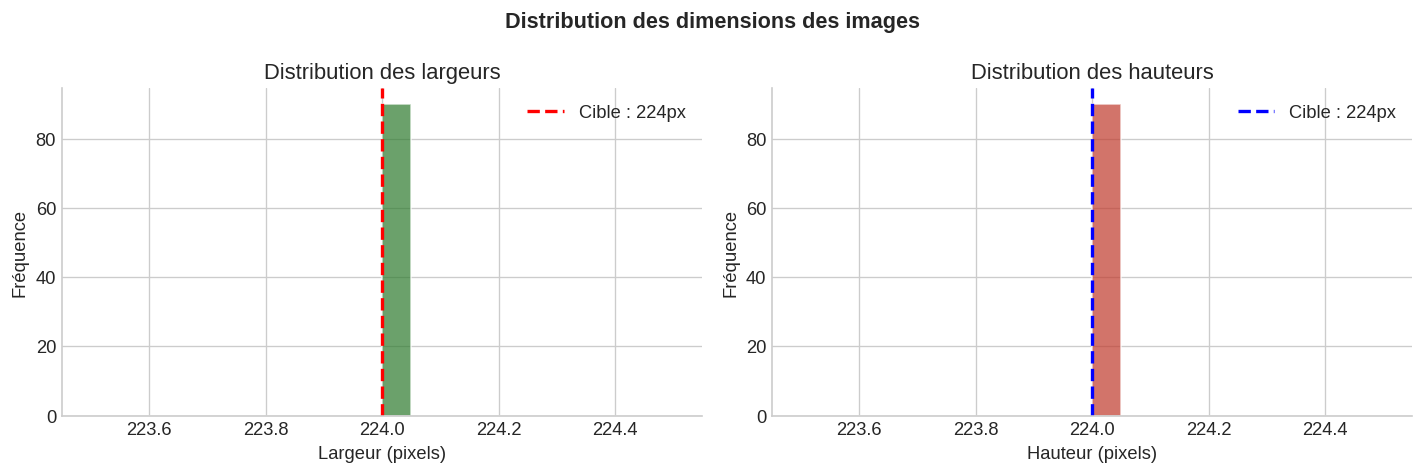

Figure sauvegardée --> /kaggle/working/03_image_dimensions.png


In [7]:
# ============================================================
# Cellule 7 — Analyse des Dimensions des Images
# On vérifie les tailles et propriétés d'un échantillon d'images
# ============================================================

widths, heights, file_sizes_kb = [], [], []

# Analyse d'un échantillon de 30 images par classe
for cls_name, cls_dir in class_paths.items():
    for img_name in class_samples[cls_name][:30]:
        img_path = os.path.join(cls_dir, img_name)
        img = cv2.imread(img_path)
        if img is None:
            continue
        h, w = img.shape[:2]
        widths.append(w)
        heights.append(h)
        file_sizes_kb.append(os.path.getsize(img_path) / 1024)

# Affichage des résultats
print('=' * 55)
print('Propriétés des images du dataset')
print('=' * 55)
print(f'  Largeur  (pixels) — min: {min(widths)}, max: {max(widths)}, moyenne: {int(np.mean(widths))}')
print(f'  Hauteur  (pixels) — min: {min(heights)}, max: {max(heights)}, moyenne: {int(np.mean(heights))}')
print(f'  Taille fichier    — moyenne: {np.mean(file_sizes_kb):.1f} KB')
print('=' * 55)
print(f'\n  Taille cible pour le modele : 224 x 224 x 3 (RGB)')

# Tracé de la distribution des dimensions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Distribution des dimensions des images', fontsize=13, fontweight='bold')

axes[0].hist(widths,  bins=20, color='#2d7a2d', alpha=0.7, edgecolor='white')
axes[0].axvline(224, color='red', linestyle='--', linewidth=2, label='Cible : 224px')
axes[0].set_title('Distribution des largeurs')
axes[0].set_xlabel('Largeur (pixels)')
axes[0].set_ylabel('Fréquence')
axes[0].legend()
axes[0].spines[['top', 'right']].set_visible(False)

axes[1].hist(heights, bins=20, color='#c0392b', alpha=0.7, edgecolor='white')
axes[1].axvline(224, color='blue', linestyle='--', linewidth=2, label='Cible : 224px')
axes[1].set_title('Distribution des hauteurs')
axes[1].set_xlabel('Hauteur (pixels)')
axes[1].set_ylabel('Fréquence')
axes[1].legend()
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('/kaggle/working/03_image_dimensions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée --> /kaggle/working/03_image_dimensions.png')

---
## 🎨 Cellule 8 — Analyse de la Distribution des Couleurs RGB

> **Explication :** On analyse les histogrammes de couleur (R, G, B) pour chaque classe.
> - Les **feuilles saines** ont un pic fort dans le canal **Vert (G)**
> - Les **maladies** modifient la distribution des couleurs (plus de rouge, moins de vert)
> - Cette analyse confirme que les différences entre classes sont **visuellement distinguables**
> - Le modèle CNN va exploiter ces différences de couleur pour classifier les maladies

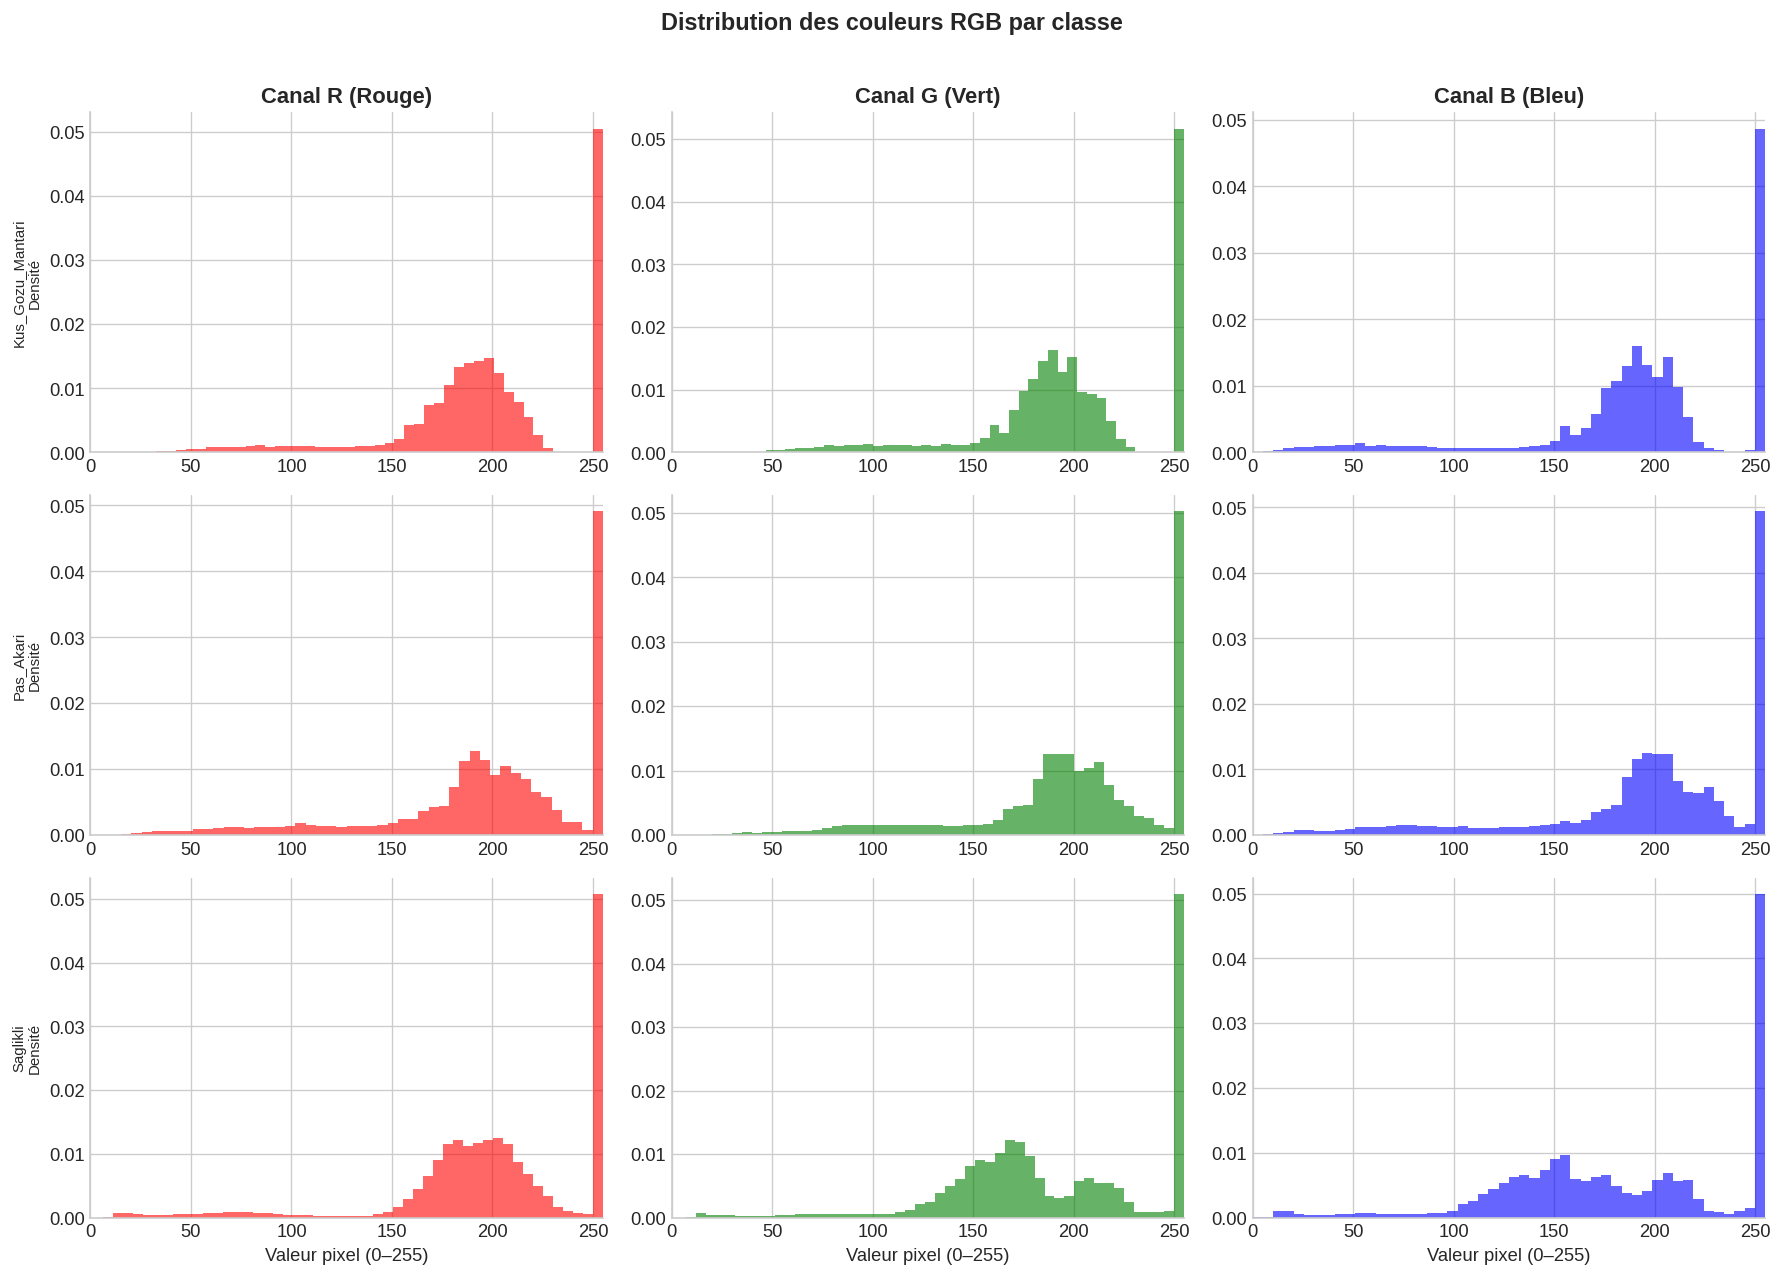

Figure sauvegardée --> /kaggle/working/04_color_distribution.png


In [8]:
# ============================================================
# Cellule 8 — Analyse de la Distribution des Couleurs RGB
# Histogrammes R, G, B pour chaque classe de maladie
# ============================================================

RGB_COLORS   = ['red', 'green', 'blue']
CHANNEL_NAMES = ['Canal R (Rouge)', 'Canal G (Vert)', 'Canal B (Bleu)']

n_classes = len(class_paths)
fig, axes = plt.subplots(n_classes, 3, figsize=(15, n_classes * 3.5))
fig.suptitle(
    'Distribution des couleurs RGB par classe',
    fontsize=14, fontweight='bold', y=1.01
)

for row, (cls_name, cls_dir) in enumerate(class_paths.items()):
    # Accumulation des pixels sur 10 images de la classe
    all_pixels = [[], [], []]  # R, G, B
    for img_name in class_samples[cls_name][:10]:
        img_path = os.path.join(cls_dir, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (224, 224))
        for ch in range(3):
            all_pixels[ch].extend(img[:, :, ch].flatten().tolist())

    # Tracé de l'histogramme pour chaque canal
    for ch in range(3):
        ax = axes[row, ch]
        ax.hist(all_pixels[ch], bins=50,
                color=RGB_COLORS[ch], alpha=0.6, density=True)
        ax.set_xlim(0, 255)
        ax.spines[['top', 'right']].set_visible(False)

        if row == 0:
            ax.set_title(CHANNEL_NAMES[ch], fontweight='bold')
        if row == n_classes - 1:
            ax.set_xlabel('Valeur pixel (0–255)')
        if ch == 0:
            ax.set_ylabel(f'{cls_name}\nDensité', fontsize=9)

plt.tight_layout()
plt.savefig('/kaggle/working/04_color_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée --> /kaggle/working/04_color_distribution.png')

---
## 💾 Cellule 9 — Sauvegarde de la Configuration du Projet

> **Explication :** On sauvegarde tous les paramètres du projet dans un fichier `config.json`.
> - Ce fichier sera **rechargé dans tous les notebooks suivants** (NB2 à NB6)
> - Il centralise les chemins, les noms de classes, les hyperparamètres du modèle
> - Utiliser un fichier de config est une **bonne pratique en Deep Learning** pour la reproductibilité

In [9]:
# ============================================================
# Cellule 9 — Sauvegarde de la Configuration du Projet
# On centralise tous les paramètres dans un fichier config.json
# ============================================================

config = {
    # Informations générales
    'project_name'    : 'Détection des Maladies de l Olivier',
    'encadrant'       : 'M. Abdallah Khemais',
    'notebook'        : '1/6 — Setup & Exploration',

    # Dataset
    'dataset_path'    : DATASET_PATH,
    'classes'         : list(class_counts.keys()),
    'num_classes'     : len(class_counts),
    'class_counts'    : class_counts,
    'total_images'    : sum(class_counts.values()),

    # Paramètres du modèle
    'img_size'        : 224,        # Taille d'entrée : 224×224
    'channels'        : 3,          # RGB = 3 canaux
    'batch_size'      : 32,         # Taille de batch
    'epochs'          : 30,         # Nombre d'époques d'entraînement
    'learning_rate'   : 1e-4,       # Taux d'apprentissage initial
    'model_name'      : 'EfficientNetB4',

    # Splits
    'train_split'     : 0.70,       # 70% entraînement
    'val_split'       : 0.15,       # 15% validation
    'test_split'      : 0.15,       # 15% test

    # Chemins de sortie
    'output_dir'      : '/kaggle/working/',
    'model_save_path' : '/kaggle/working/olive_efficientnetb4_best.h5',
    'tflite_path'     : '/kaggle/working/olive_model.tflite',
}

# Sauvegarde dans un fichier JSON
config_path = '/kaggle/working/config.json'
with open(config_path, 'w', encoding='utf-8') as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

# Récapitulatif
print('=' * 55)
print('Configuration sauvegardée avec succès !')
print('=' * 55)
print(f'  Fichier config   : {config_path}')
print(f'  Projet           : {config["project_name"]}')
print(f'  Classes          : {config["classes"]}')
print(f'  Total images     : {config["total_images"]:,}')
print(f'  Taille image     : {config["img_size"]}x{config["img_size"]}x{config["channels"]}')
print(f'  Modèle           : {config["model_name"]}')
print(f'  Epochs           : {config["epochs"]}')
print(f'  Batch size       : {config["batch_size"]}')
print(f'  Learning rate    : {config["learning_rate"]}')
print(f'  Split Train/Val/Test : {config["train_split"]*100:.0f}% / {config["val_split"]*100:.0f}% / {config["test_split"]*100:.0f}%')
print('=' * 55)

Configuration sauvegardée avec succès !
  Fichier config   : /kaggle/working/config.json
  Projet           : Détection des Maladies de l Olivier
  Classes          : ['Kus_Gozu_Mantari', 'Pas_Akari', 'Saglikli']
  Total images     : 980
  Taille image     : 224x224x3
  Modèle           : EfficientNetB4
  Epochs           : 30
  Batch size       : 32
  Learning rate    : 0.0001
  Split Train/Val/Test : 70% / 15% / 15%


---
## ✅ Récapitulatif du Notebook 1

| Cellule | Tâche | Statut |
|---------|-------|--------|
| 1 | Vérification GPU | ✅ |
| 2 | Import des librairies | ✅ |
| 3 | Exploration de la structure | ✅ |
| 4 | Statistiques par classe | ✅ |
| 5 | Visualisation distribution | ✅ |
| 6 | Exemples visuels | ✅ |
| 7 | Analyse des dimensions | ✅ |
| 8 | Distribution des couleurs RGB | ✅ |
| 9 | Sauvegarde config.json | ✅ |

---

### 📁 Fichiers générés dans `/kaggle/working/` :
- `config.json` — Configuration complète du projet
- `01_class_distribution.png` — Bar + Pie Chart
- `02_sample_images.png` — Exemples par classe
- `03_image_dimensions.png` — Distribution des tailles
- `04_color_distribution.png` — Histogrammes RGB

---

### 🚀 Prochain Notebook — NB2 : Preprocessing & Data Augmentation
- Normalisation des pixels (0–255 → 0–1)
- Data Augmentation (flip, rotation, zoom, brightness, contrast)
- Split Train / Validation / Test (70% / 15% / 15%)
- Construction du pipeline `tf.data` optimisé pour le GPU